In [1]:
import os

import platform

import torch
import numpy as np
import pandas as pd

from time import time
from tqdm import tqdm

from scipy.interpolate import griddata

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Circle, Rectangle

from matplotlib.lines import Line2D

In [37]:
def haversine_distance(array1, array2):
    """
    Compute the Haversine distance between corresponding points in two arrays.

    Parameters:
    array1 (np.ndarray): First array of shape (n, 2) [lon, lat] in degrees.
    array2 (np.ndarray): Second array of shape (n, 2) [lon, lat] in degrees.

    Returns:
    np.ndarray: Distances between corresponding points in meters.
    """
    # Convert degrees to radians
    lon1, lat1 = np.radians(array1[:, 0]), np.radians(array1[:, 1])
    lon2, lat2 = np.radians(array2[:, 0]), np.radians(array2[:, 1])

    # Differences in coordinates
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula components
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Earth radius in kilometers (mean radius = 6371 km)
    R = 6371
    return R * c

def compute_rmse(array1, array2):
    """
    Compute RMSE for geographic coordinates using Haversine distance.

    Parameters:
    array1 (np.ndarray): First array of shape (n, 2).
    array2 (np.ndarray): Second array of shape (n, 2).

    Returns:
    float: RMSE in meters.
    """
    distances = haversine_distance(array1, array2)
    return np.sqrt(np.mean(distances**2))


# Apply a style for better aesthetics
# plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif' # Font settings (Consider using LaTeX for text rendering if your paper uses LaTeX)
plt.rcParams['font.size'] = 12  # Base font size
plt.rcParams['axes.labelsize'] = 14 # Font size for x and y labels
plt.rcParams['axes.titlesize'] = 16 # Font size for the title
plt.rcParams['xtick.labelsize'] = 12 # Font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12 # Font size for y-axis tick labels
plt.rcParams['legend.fontsize'] = 12 # Font size for legend
plt.rcParams['figure.dpi'] = 300


cond_alpha = lambda t: 1 - (1-eps_alpha)*t

# conditional sigma^2
cond_sigma_sq = lambda t: eps_beta + t * (1 - eps_beta)

# drift function of forward SDE
f = lambda t: -(1-eps_alpha) / cond_alpha(t)

# diffusion function of forward SDE
g_sq = lambda t: 1 - 2 * f(t) * cond_sigma_sq(t)
g = lambda t: np.sqrt(g_sq(t))

# generate sample with reverse SDE
def reverse_SDE(x0, score_likelihood=None, time_steps=100,
                drift_fun=f, diffuse_fun=g, alpha_fun=cond_alpha, sigma2_fun=cond_sigma_sq,  save_path=False):
    # x_T: sample from standard Gaussian
    # x_0: target distribution to sample from

    # reverse SDE sampling process
    # N1 = x_T.shape[0]
    # N2 = x0.shape[0]
    # d = x_T.shape[1]

    # Generate the time mesh
    dt = 1.0/time_steps

    # Initialization
    xt = torch.randn(ensemble_size, n_dim, device=device)
    t = 1.0

    # define storage
    if save_path:
        path_all = [xt]
        t_vec = [t]

    # forward Euler sampling
    for i in range(time_steps):
        # prior score evaluation
        alpha_t = alpha_fun(t)
        sigma2_t = sigma2_fun(t)

        # Evaluate the diffusion term
        diffuse = diffuse_fun(t)

        # Evaluate the drift term
        # drift = drift_fun(t)*xt - diffuse**2 * score_eval

        # Update
        if score_likelihood is not None:
            xt += - dt*( drift_fun(t)*xt + diffuse**2 * ( (xt - alpha_t*x0)/sigma2_t) - diffuse**2 * score_likelihood(xt, t) ) \
                  + np.sqrt(dt)*diffuse*torch.randn_like(xt)
        else:
            xt += - dt*( drift_fun(t)*xt + diffuse**2 * ( (xt - alpha_t*x0)/sigma2_t) ) + np.sqrt(dt)*diffuse*torch.randn_like(xt)

        # Store the state in the path
        if save_path:
            path_all.append(xt)
            t_vec.append(t)

        # update time
        t = t - dt

    if save_path:
        return path_all, t_vec
    else:
        return xt

# the lorenz drift
lorenz96_drift = lambda x: 2*x

# lorenz system
n_dim = 2500
SDE_sigma = 0.5

# filtering setup
dt = 0.05
filtering_steps = 30

# observation sigma
obs_sigma = 0.1

####################################################################
# EnSF setup
# define the diffusion process
eps_alpha = 0.96
eps_beta = 0.03
# ensemble size
ensemble_size = 100

# forward Euler step
euler_steps = 100

# damping function(tau(0) = 1;  tau(1) = 0;)
g_tau = lambda t: 1-t

In [3]:
# computation setting
torch.set_default_dtype(torch.float64) # half precision
device = torch.device('cuda')

eps_alpha_list, eps_beta_list = np.round(np.arange(0.8, 1, 0.01), 2), np.round(np.arange(0.01, 0.2, 0.01), 2)

tune_result = []


try:
    import pickle

    with open('tune_result.pkl', 'rb') as f:
        tune_result = pickle.load(f)

except:
    # for eps_alpha, eps_beta in hyper_pairwise_list:
    for eps_alpha in tqdm(eps_alpha_list):
        for eps_beta in eps_beta_list:
            ####################################################################
            ####################################################################
            # initial state
            angles = np.linspace(-2 * np.pi, 2 * np.pi, int(n_dim/2), endpoint=False)
            x = 1.00 * np.cos(angles)
            y = 1.00 * np.sin(angles)
            state_target = torch.tensor(np.vstack((x, y)).T.flatten(), device=device)

            # filtering initial ensemble
            x = 1.15 * np.cos(angles)
            y = 1.05 * np.sin(angles)
            x_prop = torch.tensor(np.vstack((x, y)).T.flatten(), device=device) # Initial set up

            x_state = x_prop.repeat(ensemble_size, 1) + 0.1 * torch.randn(ensemble_size, n_dim, device=device)

            torch.manual_seed(114514)
            torch.cuda.empty_cache()

            rmse_sf = [compute_rmse(state_target.reshape(-1,2).cpu().numpy(), x_prop.reshape(-1,2).cpu().numpy())]

            for i in range(filtering_steps):
                x_prop += dt*lorenz96_drift(x_prop)
                # prediction step ############################################
                # state forward in time
                x_state += dt*lorenz96_drift(x_state) + np.sqrt(dt)*SDE_sigma*torch.randn_like(x_state)

                # ensemble prediction (Ground Truth)
                state_target += dt*lorenz96_drift(state_target) + np.sqrt(dt)*SDE_sigma*torch.randn_like(state_target)

                # update step ################################################
                # get observation
                # obs = torch.atan(state_target) + torch.randn_like(state_target)*obs_sigma
                obs = 0.25 * state_target + torch.randn_like(state_target) * obs_sigma

                # define likelihood score
                # obs: (d)
                # xt: (ensemble, d)
                # score_likelihood = lambda xt, t: -(torch.atan(xt) - obs)/obs_sigma**2 * (1./(1. + xt**2)) * g_tau(t)
                score_likelihood = lambda xt, t: -(0.25*xt - obs) / obs_sigma**2 * g_tau(t) * 0.25

                # generate posterior sample
                x_state = reverse_SDE(x0=x_state, score_likelihood=score_likelihood, time_steps=euler_steps)

                # get state estimates
                x_est = torch.mean(x_state, dim=0)

                # get rmse
                rmse_ensf = compute_rmse(x_est.reshape(-1,2).cpu().numpy(), state_target.reshape(-1,2).cpu().numpy())#torch.sqrt(torch.mean((x_est - state_target)**2)).item()
                rmse_ori = compute_rmse(x_est.reshape(-1,2).cpu().numpy(), (4*obs).reshape(-1,2).cpu().numpy())#torch.sqrt(torch.mean((x_prop - state_target)**2)).item()

                rmse_sf.append(rmse_ensf)
                
                if x_state.device.type == 'cuda':
                    torch.cuda.current_stream().synchronize() # Wait for all kernels in all streams on a CUDA device to complete.
                if rmse_ensf > 1000:
                    print('diverge!')
                    break

            tune_result.append([eps_alpha, eps_beta, rmse_sf])

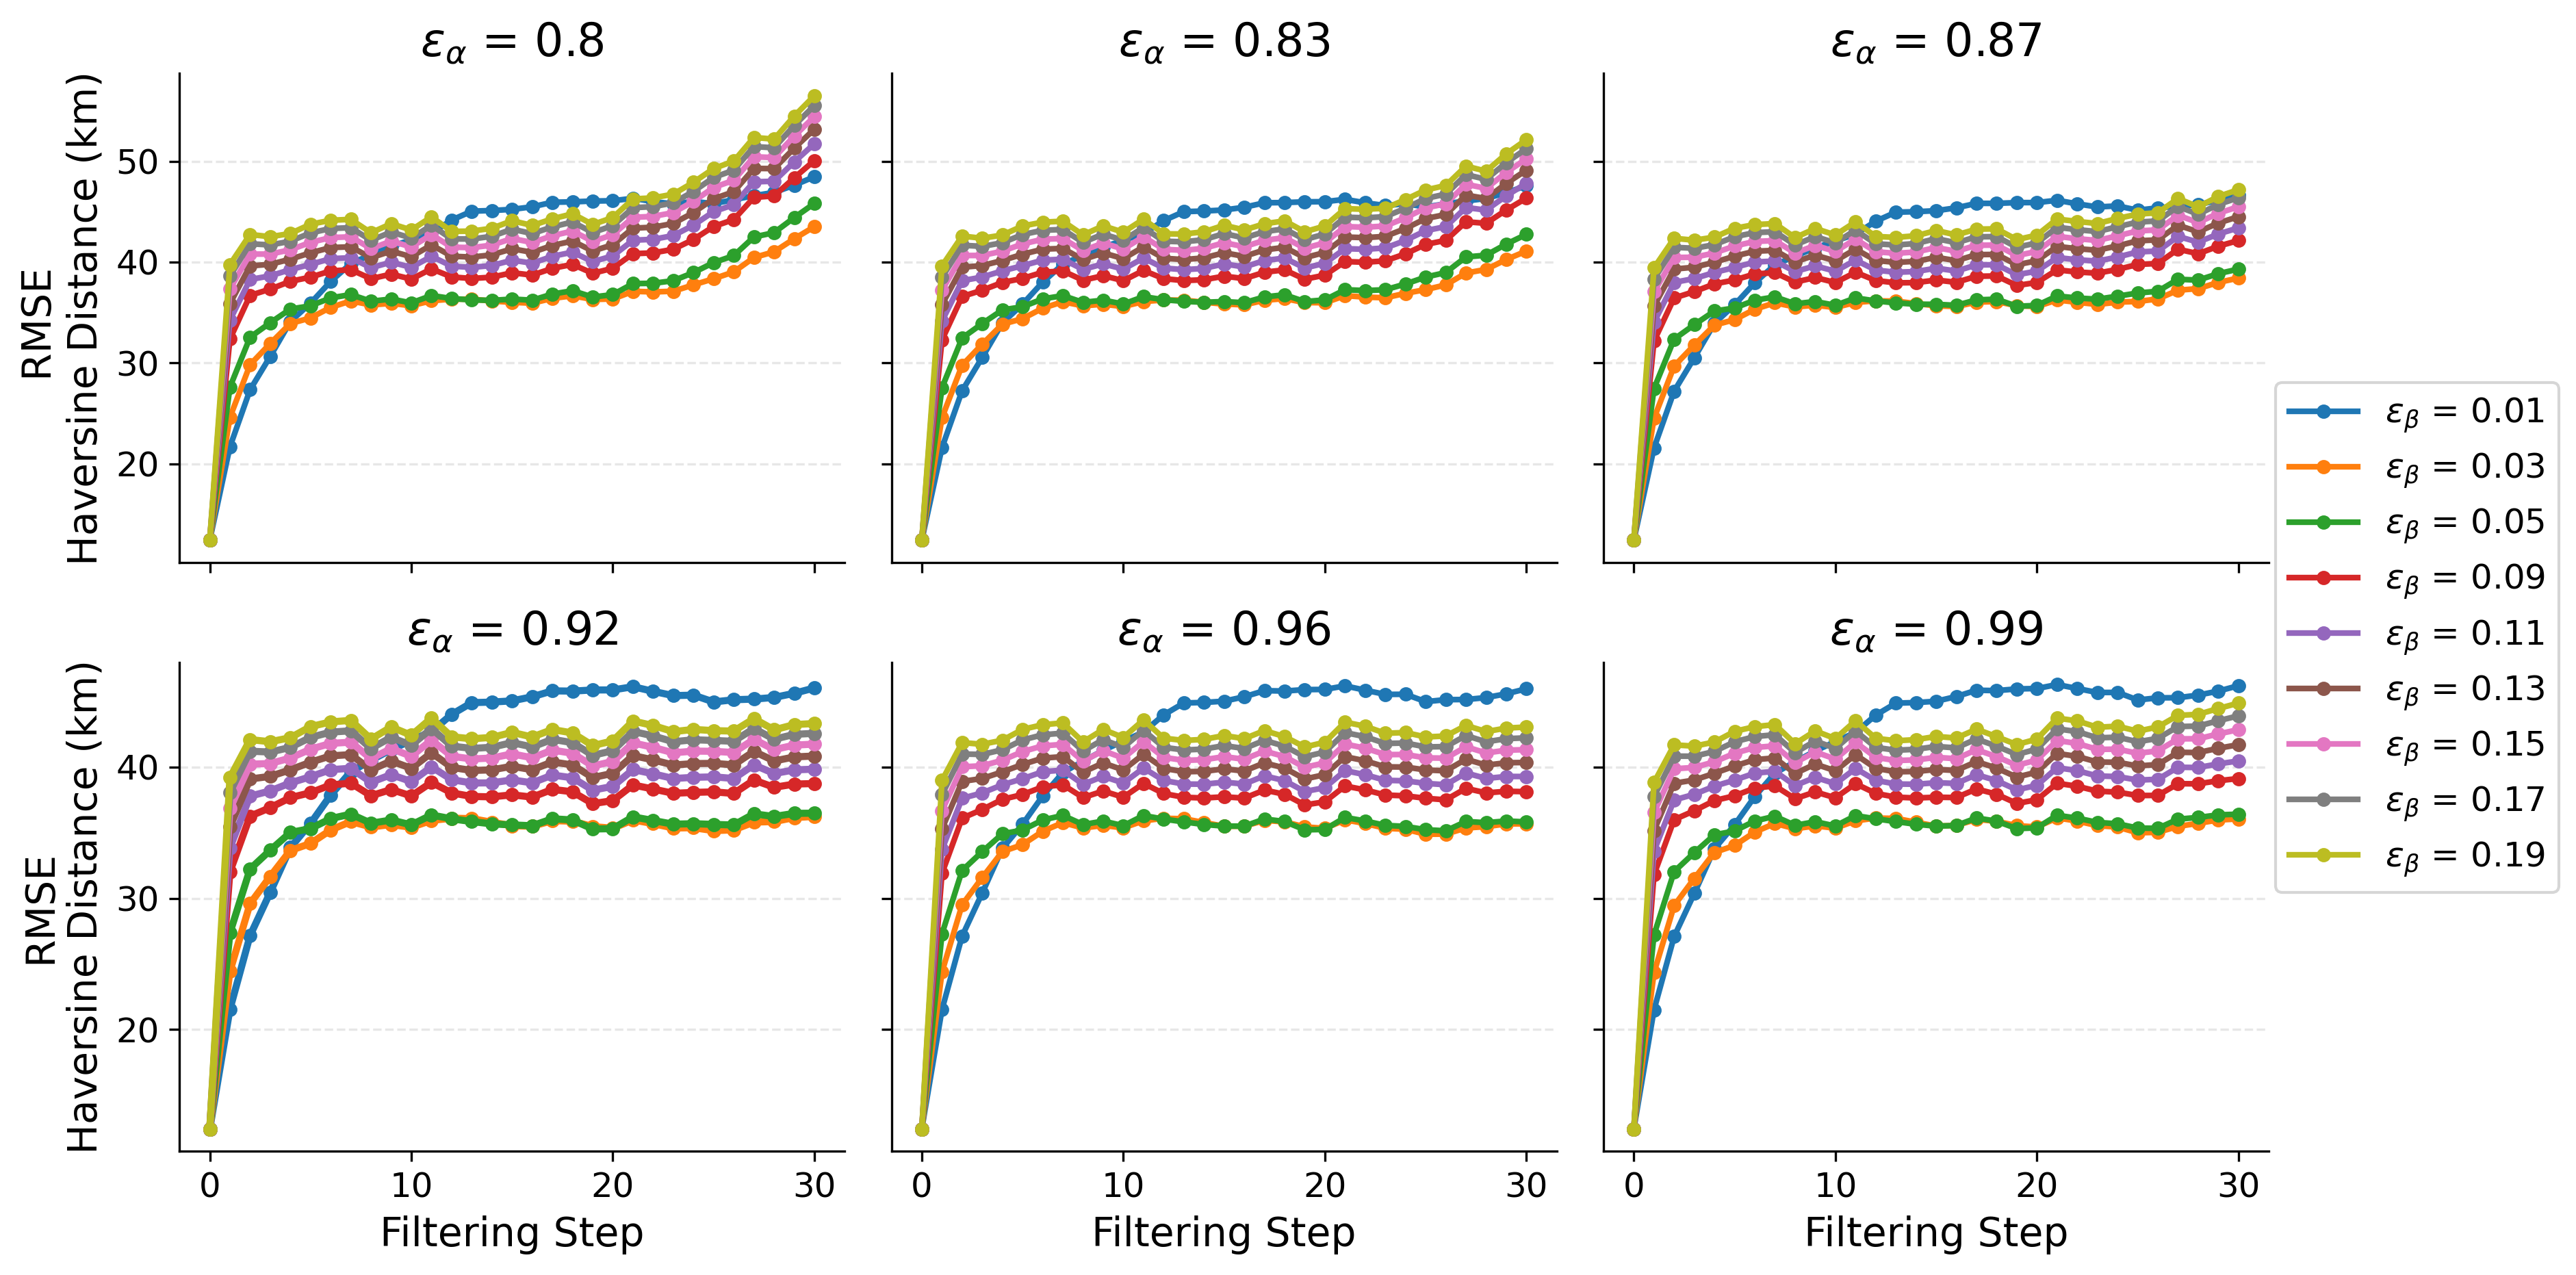

In [47]:
rmse_len = np.arange(-1, filtering_steps) + 1

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize=(13, 7), 
                         sharex='col', sharey='row')

ax80, ax83, ax87, ax92, ax96, ax99 = axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]


for i, d in enumerate(tune_result):
    alpha_temp, beta_temp, rmse_temp = d
    
    if alpha_temp == 0.8 and (beta_temp * 100)%2 == 1:
        ax80.plot(rmse_len, rmse_temp, 
            linewidth=2, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax80.set_ylabel('RMSE \nHaversine Distance (km)')
        ax80.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')
    elif alpha_temp == 0.83 and (beta_temp * 100)%2 == 1:
        ax83.plot(rmse_len, rmse_temp, 
            linewidth=2, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax83.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')
    elif alpha_temp == 0.87 and (beta_temp * 100)%2 == 1:
        ax87.plot(rmse_len, rmse_temp, 
            linewidth=2, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax87.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')
    elif alpha_temp == 0.92 and (beta_temp * 100)%2 == 1:
        ax92.plot(rmse_len, rmse_temp, 
            linewidth=2.5, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax92.set_ylabel('RMSE\nHaversine Distance (km)')
        ax92.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')
        ax92.set_xlabel('Filtering Step')
    elif alpha_temp == 0.96 and (beta_temp * 100)%2 == 1:
        ax96.plot(rmse_len, rmse_temp, 
            linewidth=2, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax96.set_xlabel('Filtering Step')
        ax96.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')
    elif alpha_temp == 0.99 and (beta_temp * 100)%2 == 1:
        ax99.plot(rmse_len, rmse_temp, 
            linewidth=2, 
            marker='o', 
            markersize=4, 
            label=rf'$\epsilon_\beta$ = {beta_temp}', 
            zorder=3)
        ax99.set_xlabel('Filtering Step')
        ax99.set_title(rf'$\epsilon_\alpha$ = {alpha_temp}')

for ax in [ax80, ax83, ax87, ax92, ax96, ax99]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# 1. Extract handles and labels from one of the axes (assuming they are all the same)
handles, labels = ax80.get_legend_handles_labels()

# 2. Create a figure-level legend on the left
# bbox_to_anchor=(x, y): (0.01, 0.5) places it at the far left, vertically centered.
# loc='center left': aligns the legend's left-center to the anchor point.
fig.legend(handles, labels, loc='center right')

# 3. Adjust the layout to make room on the left
# The first value of rect is the left margin. 
# Increase it (e.g., from 0.03 to 0.12) to push the subplots to the right.
plt.tight_layout(rect=[0.03, 0.03, 0.90, 0.94])
plt.savefig('sim_para_dana.pdf', bbox_inches='tight')
plt.show()

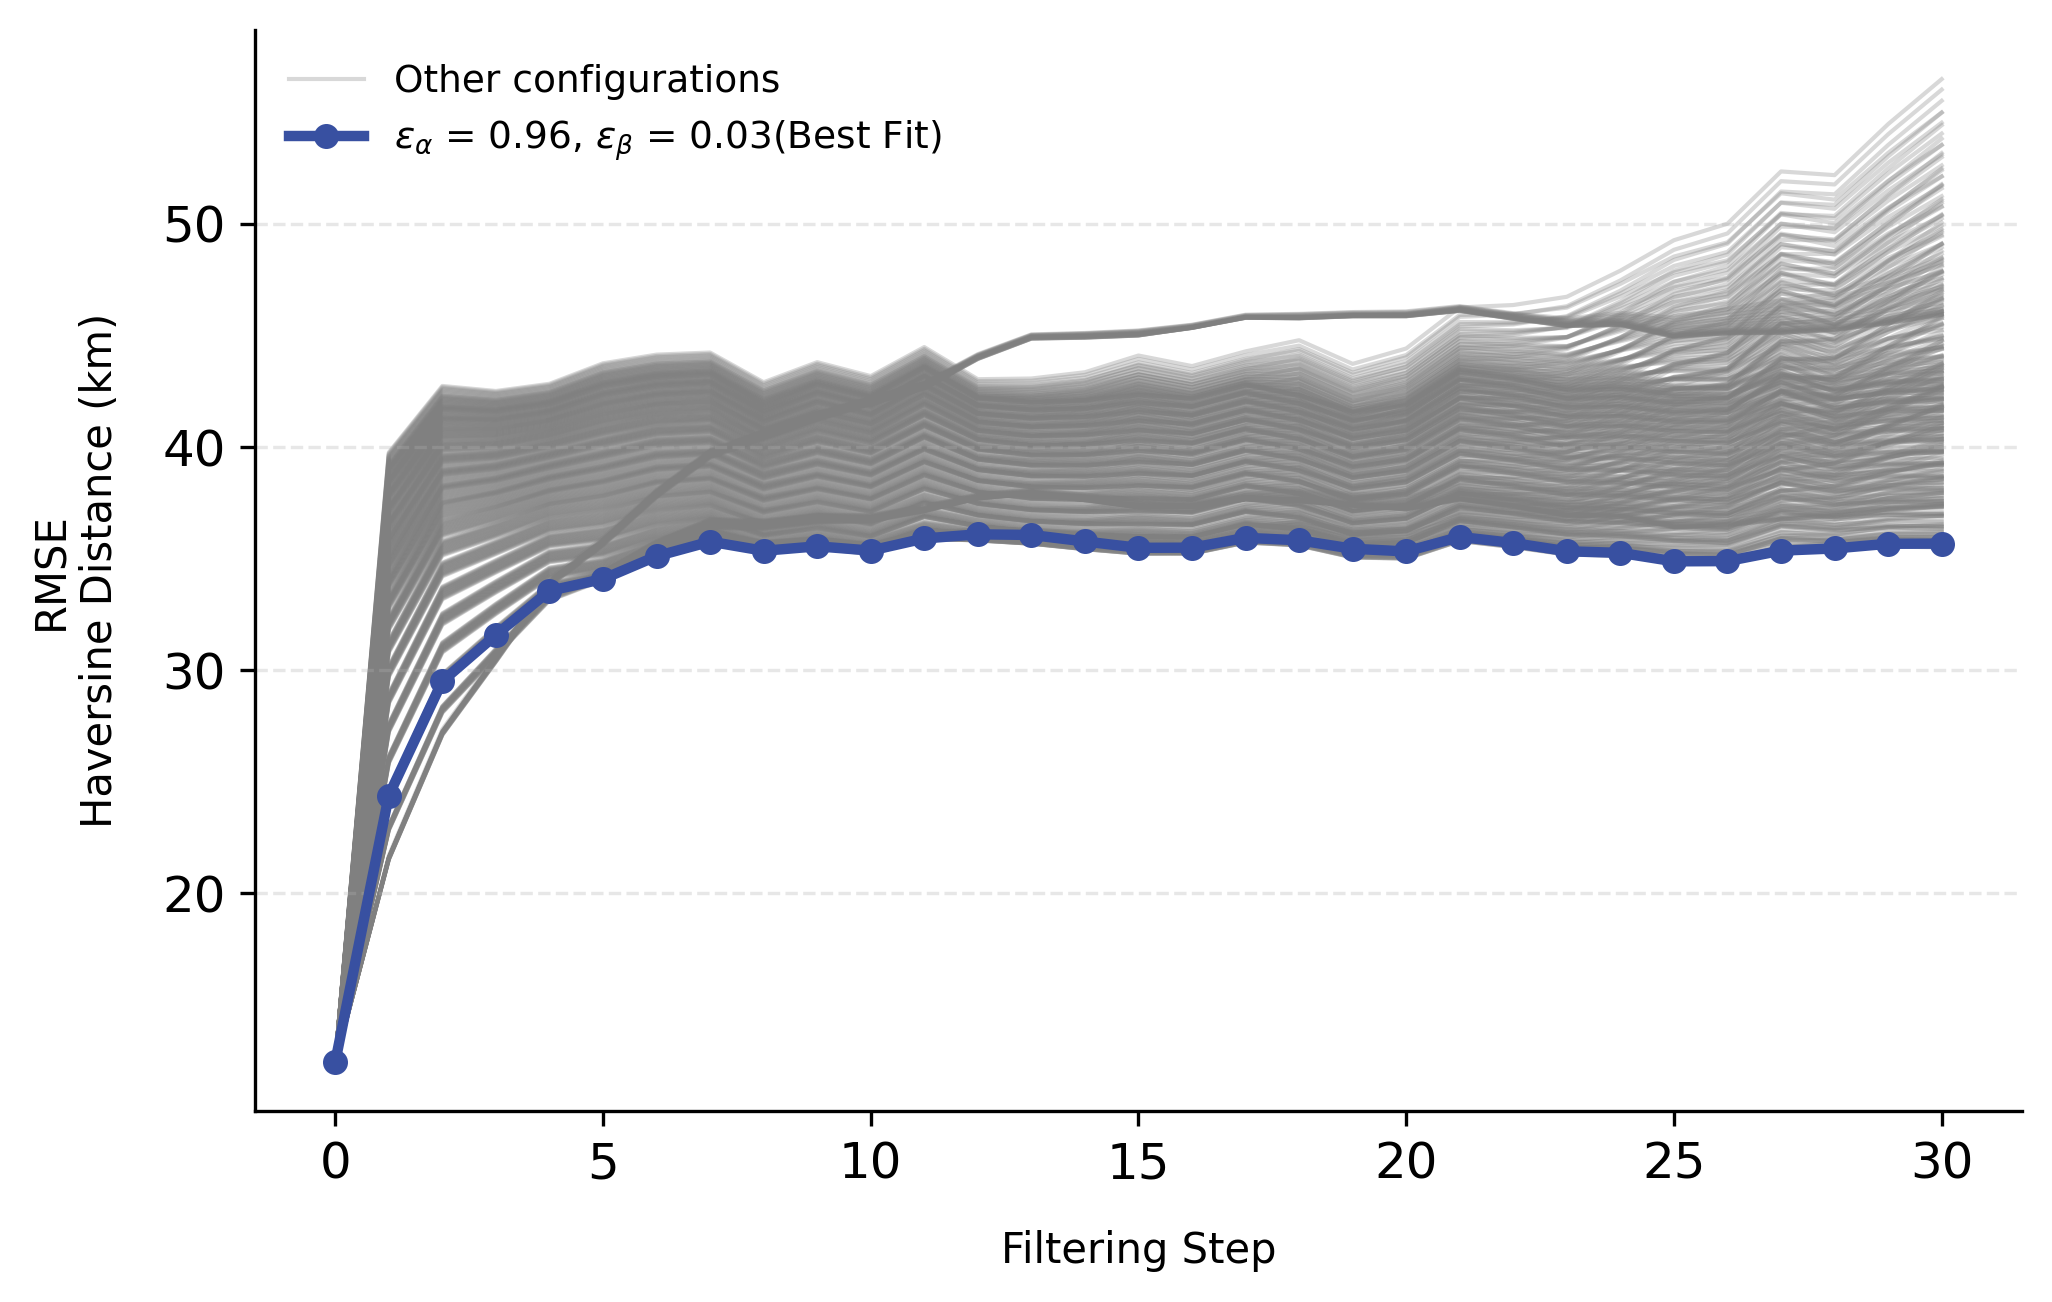

In [34]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

# We use flags to ensure we only add the "Others" label to the legend once
label_added = False 

rmse_len = np.arange(-1, filtering_steps) + 1

for d in tune_result:
    alpha_temp, beta_temp, rmse_temp = d
    
    if alpha_temp == 0.96 and beta_temp == 0.03:
        # HIGH VISIBILITY FOR TARGET
        # zorder=3 ensures this line sits ON TOP of the grey lines
        ax.plot(rmse_len, rmse_temp, 
                color='#3850a1', 
                linewidth=2.5, 
                marker='o', 
                markersize=5, 
                label=rf'$\epsilon_\alpha$ = {alpha_temp}, $\epsilon_\beta$ = {beta_temp}(Best Fit)', 
                zorder=3)
        
        # Add a direct text annotation pointing to the stable region
        # Adjust indices [-5] based on where your data stabilizes
        final_x, final_y = rmse_len[-1], rmse_temp[-1]
        
    else:
        # LOW VISIBILITY FOR CONTEXT
        # No markers, thin lines, high transparency
        label = "Other configurations" if not label_added else ""
        ax.plot(rmse_len, rmse_temp, 
                color='grey', 
                linewidth=1, 
                alpha=0.3, 
                zorder=1,
                label=label)
        label_added = True


# --- STYLING ---
ax.set_xlabel("Filtering Step", fontsize=10, labelpad=10)
ax.set_ylabel('RMSE\nHaversine Distance (km)', fontsize=10, labelpad=10)

# Clean Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Add a light grid for readability (common in journals), but keep it subtle
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Simplified Legend
# We only show the blue line and one grey line entry
plt.legend(frameon=False, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('sim_para_ana.pdf')
plt.show()

In [38]:
# computation setting
torch.set_default_dtype(torch.float64) # half precision
device = torch.device('cuda')
torch.cuda.empty_cache()
####################################################################
####################################################################
# initial state
angles = np.linspace(-2 * np.pi, 2 * np.pi, int(n_dim/2), endpoint=False)
x = 1.00 * np.cos(angles)
y = 1.00 * np.sin(angles)
state_target = torch.tensor(np.vstack((x, y)).T.flatten(), device=device)

# filtering initial ensemble
x = 1.15 * np.cos(angles)
y = 1.05 * np.sin(angles)
x_prop = torch.tensor(np.vstack((x, y)).T.flatten(), device=device) # Initial set up

x_state = x_prop.repeat(ensemble_size, 1) + 0.1 * torch.randn(ensemble_size, n_dim, device=device)

torch.manual_seed(114514)
np.random.seed(114514)
torch.cuda.empty_cache()

columns =[1, 15, 29]#[1] + [i for i in range(30) if i % 10 == 9]
num_plot_a_cols = len(columns)

# info containers
rmse_all = [compute_rmse(state_target.reshape(-1,2).cpu().numpy(), x_prop.reshape(-1,2).cpu().numpy())]
rmse_ori = [compute_rmse(state_target.reshape(-1,2).cpu().numpy(), x_prop.reshape(-1,2).cpu().numpy())]
state_save = []
est_save = []

state_kf = []
gt = []

gt_save = []

# filtering cycles
for i in tqdm(range(filtering_steps)):
    x_prop += dt*lorenz96_drift(x_prop)
    # prediction step ############################################
    # state forward in time
    x_state += dt*lorenz96_drift(x_state) + np.sqrt(dt)*SDE_sigma*torch.randn_like(x_state)

    # ensemble prediction (Ground Truth)
    state_target += dt*lorenz96_drift(state_target) + np.sqrt(dt)*SDE_sigma*torch.randn_like(state_target)

    gt.append(state_target.clone())

    # update step ################################################
    # get observation
    # obs = torch.atan(state_target) + torch.randn_like(state_target)*obs_sigma
    obs = 0.25 * state_target + torch.randn_like(state_target) * obs_sigma

    # define likelihood score
    # obs: (d)
    # xt: (ensemble, d)
    # score_likelihood = lambda xt, t: -(torch.atan(xt) - obs)/obs_sigma**2 * (1./(1. + xt**2)) * g_tau(t)
    score_likelihood = lambda xt, t: -(0.25*xt - obs) / obs_sigma**2 * g_tau(t) * 0.25

    # generate posterior sample
    x_state = reverse_SDE(x0=x_state, score_likelihood=score_likelihood, time_steps=euler_steps)
    # get state estimates
    x_est = torch.mean(x_state, dim=0)

    if x_state.device.type == 'cuda':
        torch.cuda.current_stream().synchronize() #Wait for all kernels in all streams on a CUDA device to complete.

    if i in columns:
        state_save.append(x_state.clone())
        est_save.append(x_est.clone())
        gt_save.append(state_target.clone())

state_save = torch.stack(state_save, dim=0).cpu().numpy()
est_save = torch.stack(est_save, dim=0).cpu().numpy()
gt_save = torch.stack(gt_save, dim=0).cpu().numpy()

# Initialize ensemble
x = 1.00 * np.cos(angles)
y = 1.00 * np.sin(angles)
state_target = torch.tensor(np.vstack((x, y)).T.flatten(), device=device)

x_init_coords = 1.15 * np.cos(angles) # Changed variable name for clarity
y_init_coords = 1.05 * np.sin(angles) # Changed variable name for clarity
x_prop = torch.tensor(np.vstack((x_init_coords, y_init_coords)).T.flatten(), device=device) # Initial set up
x_state = x_prop.repeat(ensemble_size, 1) + 0.1 * torch.randn(ensemble_size, n_dim, device=device)

H = 0.25 * torch.eye(n_dim, device=device)

# Information containers
state_kf = []
est_kf = []

torch.set_default_dtype(torch.float64) # half precision
torch.manual_seed(114514)
torch.cuda.empty_cache()

t = 0

# EnKF implementation
for i in tqdm(range(filtering_steps)):
    time1 = time()
    x_state += dt*lorenz96_drift(x_state) + np.sqrt(dt)*SDE_sigma*torch.randn_like(x_state)
    
    state_target = gt[i]

    y = 0.25 * state_target + obs_sigma * torch.randn(n_dim, device=device) # observation

    x_mean = torch.mean(x_state, axis=0)
    e_x = x_state - x_mean

    P = e_x.T @ e_x / (ensemble_size - 1)

    y_perturbed = y.unsqueeze(0).repeat(ensemble_size, 1)
    y_perturbed += obs_sigma * torch.randn(ensemble_size, n_dim, device=device)

    Hx = 0.25 * x_state  # 应用观测算子 H = 0.25*I
    Hx_mean = torch.mean(Hx, axis=0)
    e_Hx = Hx - Hx_mean

    P_yy = e_Hx.T @ e_Hx / (ensemble_size - 1) + torch.eye(n_dim, device=device) * (obs_sigma**2)
    P_xy = e_x.T @ e_Hx / (ensemble_size - 1)

    K = P_xy @ torch.linalg.inv(P_yy)

    x_state = x_state + (y_perturbed - Hx) @ K.T

    x_est = torch.mean(x_state, axis=0)
    t += time() - time1
    if x_state.device.type == 'cuda':
        torch.cuda.current_stream().synchronize()
    if i in columns:
        state_kf.append(x_state.clone())
        est_kf.append(x_est.clone())

# Convert results to numpy array
state_kf = torch.stack(state_kf, dim=0).cpu().numpy()
est_kf = torch.stack(est_kf, dim=0).cpu().numpy()

100%|██████████| 30/30 [00:14<00:00,  2.09it/s]


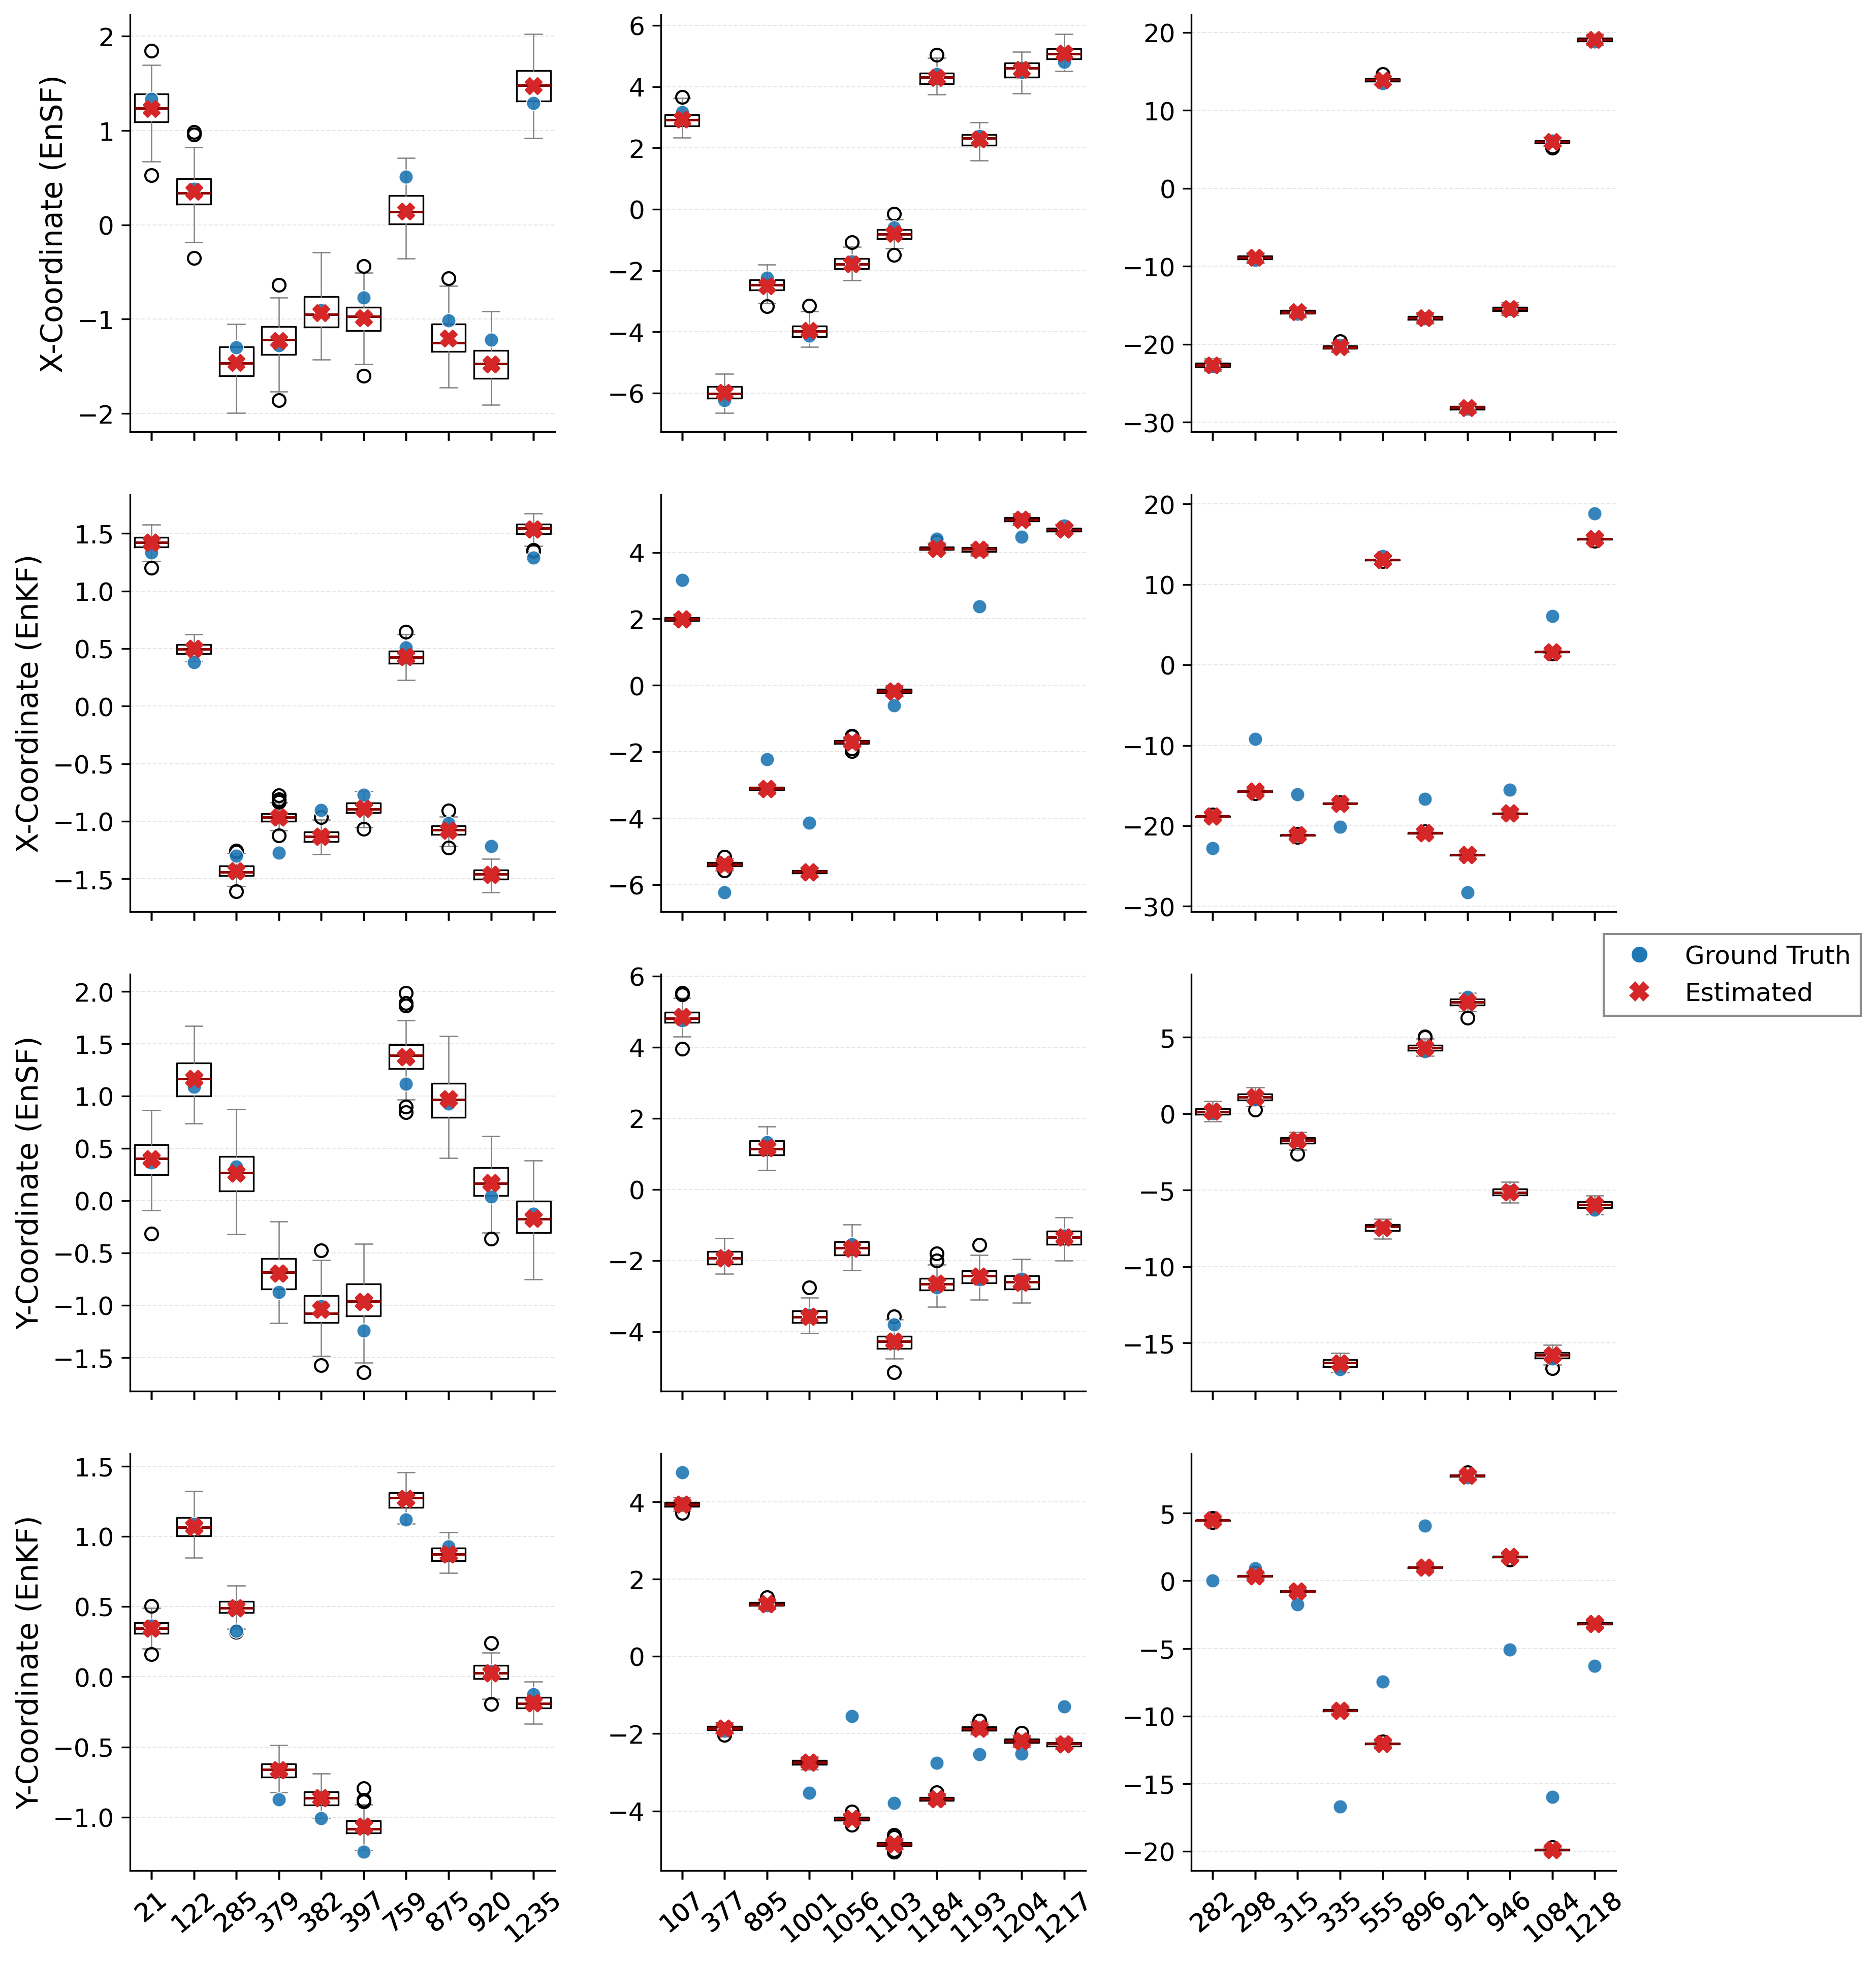

In [ ]:
np.random.seed(114514)

columns =[1, 15, 29]#[1] + [i for i in range(30) if i % 10 == 9]
num_plot_cols = len(columns)

fig, axes = plt.subplots(nrows=4, ncols=num_plot_cols,
                            figsize=(13, 14),
                            sharex='col')

for col in range(num_plot_cols):
    sf_x_plt, kf_x_plt, sf_y_plt, kf_y_plt = axes[:, col]

    num_rand_idx = np.sort(np.random.randint(0, int(n_dim / 2), 10))

    x_positions = np.arange(1, len(num_rand_idx) + 1)

    ensf_x, ensf_y = state_save[col][:,2 * num_rand_idx], state_save[col][:,2 * num_rand_idx + 1]
    enkf_x, enkf_y = state_kf[col][:,2 * num_rand_idx], state_kf[col][:,2 * num_rand_idx + 1]

    ensf_x_est, ensf_y_est = est_save[col,2 * num_rand_idx], est_save[col,2 * num_rand_idx + 1]
    enkf_x_est, enkf_y_est = est_kf[col,2 * num_rand_idx], est_kf[col,2 * num_rand_idx + 1]

    gt_x, gt_y = gt_save[col,2 * num_rand_idx], gt_save[col,2 * num_rand_idx + 1]

    boxprops = dict(linewidth=0.8, color='black')
    whiskerprops = dict(linewidth=0.6, color='gray')
    capprops = dict(linewidth=0.6, color='gray')
    medianprops = dict(linewidth=1.2, color='darkred')
    
    sf_x_plt.boxplot(ensf_x, tick_labels=num_rand_idx, widths=0.8,
                     boxprops=boxprops, whiskerprops=whiskerprops,
                     capprops=capprops, medianprops=medianprops)  # 不要异常值，看着乱
    
    sf_y_plt.boxplot(ensf_y, tick_labels=num_rand_idx, widths=0.8, 
                     boxprops=boxprops, whiskerprops=whiskerprops,
                     capprops=capprops, medianprops=medianprops)
    
    kf_x_plt.boxplot(enkf_x, tick_labels=num_rand_idx, widths=0.8,
                     boxprops=boxprops, whiskerprops=whiskerprops,
                     capprops=capprops, medianprops=medianprops)
    
    kf_y_plt.boxplot(enkf_y, tick_labels=num_rand_idx, widths=0.8,
                     boxprops=boxprops, whiskerprops=whiskerprops,
                     capprops=capprops, medianprops=medianprops)
    
    if col == 0:
        sf_x_plt.set_ylabel("X-Coordinate (EnSF)", fontweight='medium')
        sf_y_plt.set_ylabel("Y-Coordinate (EnSF)", fontweight='medium')
        kf_x_plt.set_ylabel("X-Coordinate (EnKF)", fontweight='medium')
        kf_y_plt.set_ylabel("Y-Coordinate (EnKF)", fontweight='medium')
    
    sf_x_plt.scatter(x_positions, gt_x, color='#1f77b4', 
                     edgecolor='white', linewidth=0.5,
                     s=45, zorder=10, alpha=0.9)
    sf_y_plt.scatter(x_positions, gt_y, color='#1f77b4',
                     edgecolor='white', linewidth=0.5,
                     s=45, zorder=10, alpha=0.9)
    kf_x_plt.scatter(x_positions, gt_x, color='#1f77b4',
                     edgecolor='white', linewidth=0.5,
                     s=45, zorder=10, alpha=0.9)
    kf_y_plt.scatter(x_positions, gt_y, color='#1f77b4',
                     edgecolor='white', linewidth=0.5,
                     s=45, zorder=10, alpha=0.9)
    
    sf_x_plt.scatter(x_positions, ensf_x_est, zorder=11,
                     marker='X', color='#d62728',
                     s=55, linewidth=1)
    sf_y_plt.scatter(x_positions, ensf_y_est, zorder=11,
                     marker='X', color='#d62728',
                     s=55, linewidth=1.2)
    kf_x_plt.scatter(x_positions, enkf_x_est, zorder=11,
                     marker='X', color='#d62728',
                     s=55, linewidth=1.2)
    kf_y_plt.scatter(x_positions, enkf_y_est, zorder=11,
                     marker='X', color='#d62728',
                     s=55, linewidth=1.2)
    
    for ax in [sf_x_plt, sf_y_plt, kf_x_plt, kf_y_plt]:
        ax.tick_params(axis='x', rotation=40, length=4, width=0.8)
        ax.tick_params(axis='y', length=4, width=0.8)
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)


est_scatter = Line2D([0], [0], marker='X', color='#d62728', 
                     markersize=8, linewidth=0, label='Estimated')
gt_scatter = Line2D([0], [0], marker='o', color='#1f77b4',
                    markersize=8, linewidth=0, label='Ground Truth',
                    markeredgecolor='white', markeredgewidth=0.5)


fig.legend(handles=[gt_scatter, est_scatter], 
           loc='center right', 
           bbox_to_anchor=(0.98, 0.5),
           frameon=True,
           framealpha=0.9,
           edgecolor='gray',
           fancybox=False)


plt.subplots_adjust(
    right=0.85, 
    hspace=0.15, 
    wspace=0.25,
    top=0.95,
    bottom=0.08,
    left=0.1
)

plt.savefig('sim_spread.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(13, 6))

i = 0

for fireid in [1819, 2286]:
    for period in [3, 11]:
        # ==========================================
        # 1. SETUP
        # ==========================================
        # --- Observation ---
        obs = gpd.read_file(rf"{fireid}/{i+1}/fire_boundary.shp", engine='pyogrio')

        # --- Fire-EnSF ---
        ensf = np.load(f'resub/{fireid}/ensf_{period}.npy')
        ensf_est = np.mean(ensf, axis = 0)
        ensemble_size = ensf.shape[0]
        n_sf = int(ensf.shape[1]/2)

        ensf = ensf.reshape(ensemble_size, n_sf, 2)
        
        # --- FARSITE W/ EnKF ---
        enkf = np.load(f'resub/{fireid}/enkf_{period}.npy')
        enkf_est = np.mean(enkf, axis = 0)
        n_kf = int(enkf.shape[1]/2)

        enkf = enkf.reshape(ensemble_size, n_kf, 2)

        # ==========================================
        # 2. DATA PROCESSING
        # ==========================================

        sf_area = np.array([Polygon(ens).area for ens in ensf]) / 1e6
        kf_area = np.array([Polygon(ens).area for ens in enkf]) / 1e6

        obs_area = obs.area[0] / 1e6

        sf_est_area = Polygon(ensf_est.reshape(-1, 2)).area / 1e6
        kf_est_area = Polygon(enkf_est.reshape(-1, 2)).area / 1e6

        # ==========================================
        # 3. Physical Uncertainty (Area Histogram)
        # ==========================================
        
        sf_ax, kf_ax = axes[0, i], axes[1, i]

        sf_ax.set_title(f"Fireid: {fireid}, Period {period}", fontsize = 14)

        col_indicator =  True if i == 0 else False
    
        area_hist(sf_ax, sf_area, obs_area, sf_est_area, False, col_indicator, True)
        area_hist(kf_ax, kf_area, obs_area, kf_est_area, True, col_indicator, False)        

        i += 1

legend_elements = [
    Line2D([0], [0], color='#C44E52', linestyle = 'dashed',
            lw=2, label='Obs. Area'),
    Line2D([0], [0], color='#ff9f1c', linestyle = 'dashed', 
            lw=2, label='Est. Area')
]
kf_ax.legend(handles=legend_elements, loc='upper left',
            bbox_to_anchor=(1.02, 1),
            frameon=True, framealpha=0.95)
plt.tight_layout()
plt.savefig('num_result/app_area_uq.pdf')
plt.show()